## Pre-processing Objectives:
1. Create a measure for recidivism in the entire dataset: try various approaches to this as different columns
2. Check the distribution of missing values across states
3. Clean up missing values specific to states chosen

# Import and Load Data

In [1]:
import warnings

# warnings.filterwarnings('ignore')

import pandas as pd

pd.set_option("mode.copy_on_write", True)

/var/folders/rq/6gkwkw8n79d9pw5r3y76nfqc0000gn/T/ipykernel_37835/467590385.py:7: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.set_option("mode.copy_on_write", True)


In [2]:
# load data
import os
import gdown

file_id = "1jkBkjOsdr-0hhUgj3p2J7pk1Welkk7A1"

# check if a csv was already created earlier and download only if it wasn't
if not os.path.exists("dataset.csv"):
    gdown.download(id=file_id, output="dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv", sep="\t")
df.head()

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
0,A012021000000090128,1,1,2,9,2013,2013,9999,9999,9999,4,8,1,5,5,0,3,1
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,4,3,1,5,9,9,9,1
2,A012021000000090187,1,1,2,9,2009,2009,9999,9999,9999,0,11,9,1,1,0,1,1
3,A012021000000010425,1,3,3,9,2016,2016,9999,9999,9999,2,12,9,3,3,0,3,1
4,A012021000000090117,1,1,1,9,2009,2017,9999,9999,9999,4,4,9,1,2,3,1,1


# Missing values and duplicates

In [3]:
# Check duplicates
dup_count = df.duplicated(
    subset=["ABT_INMATE_ID", "ADMITYR", "RELEASEYR"]
).sum()
print("Duplicates:", dup_count)

# Remove duplicates
df = df.drop_duplicates(
    subset=["ABT_INMATE_ID", "ADMITYR", "RELEASEYR"],
    keep="first"
)

# Confirm
print("After removal:", df.duplicated(
    subset=["ABT_INMATE_ID", "ADMITYR", "RELEASEYR"]
).sum())

Duplicates: 213506
After removal: 0


In [4]:
import numpy as np

# 9-coded missing
cols_9 = ["ADMTYPE", "OFFGENERAL", "SENTLGTH", "RACE",
          "AGEADMIT", "AGERELEASE", "TIMESRVD", "RELTYPE"]

for col in cols_9:
    df[col] = df[col].replace(9, np.nan)

# 99-coded missing
df["OFFDETAIL"] = df["OFFDETAIL"].replace(99, np.nan)

# 9999-coded missing (years)
cols_9999 = ["ADMITYR", "RELEASEYR",
             "MAND_PRISREL_YEAR", "PROJ_PRISREL_YEAR", "PARELIG_YEAR"]

for col in cols_9999:
    df[col] = df[col].replace(9999, np.nan)

In [5]:
cols_to_drop = ["PARELIG_YEAR", "MAND_PRISREL_YEAR", "PROJ_PRISREL_YEAR"]
df = df.drop(columns=cols_to_drop)

In [6]:
df = df.dropna(subset=["RELEASEYR"])

In [7]:
df = df.dropna(subset=["ADMITYR"])
print("Remaining missing ADMITYR:", df["ADMITYR"].isna().sum())

Remaining missing ADMITYR: 0


## 🧹 Data Cleaning Recap



- **Duplicate removal**:  
  Observations were deduplicated using the combination of `ABT_INMATE_ID`, `ADMITYR`, and `RELEASEYR` to retain one record per incarceration spell.

- **Sentinel value decoding**:  
  The NCRP dataset encodes missing values using specific codes (e.g., 9, 99, 9999). These were converted to `NaN` based on the codebook and applied selectively by column.

- **Dropping high-missing variables**:  
  The variables `PARELIG_YEAR`, `MAND_PRISREL_YEAR`, and `PROJ_PRISREL_YEAR` were removed due to a high proportion of missing values and limited relevance.

- **Filtering incomplete records**:  
  Observations with missing `RELEASEYR` were removed, as these individuals are still incarcerated and cannot be used in recidivism calculations.

- **Handling essential missing values**:  
  A small number of observations with missing `ADMITYR` were dropped, as admission year is required to define incarceration periods.

# Variable Construction

In [8]:
# add state names
state_map = {
    1: "Alabama",
    2: "Alaska",
    4: "Arizona",
    5: "Arkansas",
    6: "California",
    8: "Colorado",
    9: "Connecticut",
    10: "Delaware",
    11: "District of Columbia",
    12: "Florida",
    13: "Georgia",
    15: "Hawaii",
    16: "Idaho",
    17: "Illinois",
    18: "Indiana",
    19: "Iowa",
    20: "Kansas",
    21: "Kentucky",
    22: "Louisiana",
    23: "Maine",
    24: "Maryland",
    25: "Massachusetts",
    26: "Michigan",
    27: "Minnesota",
    28: "Mississippi",
    29: "Missouri",
    30: "Montana",
    31: "Nebraska",
    32: "Nevada",
    33: "New Hampshire",
    34: "New Jersey",
    35: "New Mexico",
    36: "New York",
    37: "North Carolina",
    38: "North Dakota",
    39: "Ohio",
    40: "Oklahoma",
    41: "Oregon",
    42: "Pennsylvania",
    44: "Rhode Island",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    53: "Washington",
    54: "West Virginia",
    55: "Wisconsin",
}

df["STATE_NAME"] = df["STATE"].map(state_map)

# Verify
print(df["STATE_NAME"].unique())

<StringArray>
[             'Alabama',              'Arizona',           'California',
             'Colorado',             'Delaware',              'Florida',
              'Georgia',             'Illinois',              'Indiana',
                 'Iowa',               'Kansas',             'Kentucky',
            'Louisiana',                'Maine',             'Maryland',
        'Massachusetts',             'Michigan',            'Minnesota',
          'Mississippi',             'Missouri',              'Montana',
             'Nebraska',               'Nevada',        'New Hampshire',
           'New Jersey',           'New Mexico',             'New York',
       'North Carolina',         'North Dakota',                 'Ohio',
             'Oklahoma',               'Oregon',         'Pennsylvania',
         'Rhode Island',       'South Carolina',         'South Dakota',
            'Tennessee',                'Texas',                 'Utah',
           'Washington',        'West

In [9]:
df["tot_arrest_counts"] = df.groupby("ABT_INMATE_ID")["ABT_INMATE_ID"].transform(
    "count"
)
df

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,tot_arrest_counts
0,A012021000000090128,1,1.0,2.0,9,2013.0,2013.0,4.0,8.0,1.0,5.0,5.0,0.0,3.0,1,Alabama,1
2,A012021000000090187,1,1.0,2.0,9,2009.0,2009.0,0.0,11.0,NaN,1.0,1.0,0.0,1.0,1,Alabama,1
3,A012021000000010425,1,3.0,3.0,9,2016.0,2016.0,2.0,12.0,NaN,3.0,3.0,0.0,3.0,1,Alabama,3
4,A012021000000090117,1,1.0,1.0,9,2009.0,2017.0,4.0,4.0,NaN,1.0,2.0,3.0,1.0,1,Alabama,2
5,A012021000000150055,1,1.0,1.0,9,2020.0,2020.0,2.0,4.0,1.0,2.0,2.0,0.0,1.0,1,Alabama,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13897851,A112020000001771624,1,1.0,3.0,9,2007.0,2010.0,2.0,12.0,2.0,NaN,NaN,2.0,1.0,11,District of Columbia,1
13897852,A112020000001771626,1,1.0,1.0,9,2001.0,2004.0,3.0,4.0,2.0,NaN,NaN,2.0,1.0,11,District of Columbia,2
13897853,A112020000001771626,1,1.0,1.0,9,2007.0,2013.0,4.0,4.0,2.0,NaN,NaN,3.0,1.0,11,District of Columbia,2
13897854,A112020000001771666,1,1.0,1.0,9,2010.0,2014.0,2.0,1.0,2.0,NaN,NaN,2.0,1.0,11,District of Columbia,2


In [10]:
# Step 1: Get the latest release year per inmate per year
latest_release = (
    df.groupby(["ABT_INMATE_ID", "ADMITYR"])["RELEASEYR"]
    .max()
    .reset_index()
    .rename(columns={"RELEASEYR": "LATEST_RELEASEYR"})
)

# Step 2: Get unique inmate-year combinations for future appearances
future_appearances = df[["ABT_INMATE_ID", "ADMITYR"]].drop_duplicates()

# Step 3: Self-merge to compare each inmate's latest release year against future admissions
merged = latest_release.merge(
    future_appearances, on="ABT_INMATE_ID", suffixes=("", "_FUTURE")
)

# Step 4: Check if future admission falls within 2 years after latest release
recid_flag = (
    merged[
        (merged["ADMITYR_FUTURE"] > merged["LATEST_RELEASEYR"])
        & (merged["ADMITYR_FUTURE"] <= merged["LATEST_RELEASEYR"] + 2)
    ][["ABT_INMATE_ID", "ADMITYR"]]
    .drop_duplicates()
    .assign(within_2_yrs=1)
)

# Step 5: Merge back and fill non-recidivists with 0
df = df.merge(recid_flag, on=["ABT_INMATE_ID", "ADMITYR"], how="left")
df["within_2_yrs"] = df["within_2_yrs"].fillna(0).astype(int)

In [11]:
df

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,tot_arrest_counts,within_2_yrs
0,A012021000000090128,1,1.0,2.0,9,2013.0,2013.0,4.0,8.0,1.0,5.0,5.0,0.0,3.0,1,Alabama,1,0
1,A012021000000090187,1,1.0,2.0,9,2009.0,2009.0,0.0,11.0,NaN,1.0,1.0,0.0,1.0,1,Alabama,1,0
2,A012021000000010425,1,3.0,3.0,9,2016.0,2016.0,2.0,12.0,NaN,3.0,3.0,0.0,3.0,1,Alabama,3,1
3,A012021000000090117,1,1.0,1.0,9,2009.0,2017.0,4.0,4.0,NaN,1.0,2.0,3.0,1.0,1,Alabama,2,0
4,A012021000000150055,1,1.0,1.0,9,2020.0,2020.0,2.0,4.0,1.0,2.0,2.0,0.0,1.0,1,Alabama,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12687532,A112020000001771624,1,1.0,3.0,9,2007.0,2010.0,2.0,12.0,2.0,NaN,NaN,2.0,1.0,11,District of Columbia,1,0
12687533,A112020000001771626,1,1.0,1.0,9,2001.0,2004.0,3.0,4.0,2.0,NaN,NaN,2.0,1.0,11,District of Columbia,2,0
12687534,A112020000001771626,1,1.0,1.0,9,2007.0,2013.0,4.0,4.0,2.0,NaN,NaN,3.0,1.0,11,District of Columbia,2,0
12687535,A112020000001771666,1,1.0,1.0,9,2010.0,2014.0,2.0,1.0,2.0,NaN,NaN,2.0,1.0,11,District of Columbia,2,1


## Recidivism Variable Construction

We construct a binary measure of recidivism indicating whether an individual returns to prison within two years of release.

The process is as follows:

- **Count incarceration spells**:  
  For each individual (`ABT_INMATE_ID`), we count the number of observed incarceration events.

- **Identify release timing**:  
  For each inmate–admission year pair, we determine the latest release year associated with that incarceration spell.

- **Track future admissions**:  
  We generate all future admission events for each individual by comparing each incarceration spell to all subsequent admissions.

- **Define recidivism window**:  
  An individual is classified as recidivating (`within_2_yrs = 1`) if they are readmitted to prison within two years following their release.

- **Merge results**:  
  The recidivism indicator is merged back into the main dataset, with non-recidivists assigned a value of 0.

This approach ensures that recidivism is defined consistently across all individuals and incarceration spells.

# Understanding Missing (nan) portions

In [12]:
import pandas as pd

# percentage of missing values by column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

# convert to dataframe for nicer display
missing_table = missing_pct.reset_index()
missing_table.columns = ["Variable", "Percent_NaN"]

# show only columns with at least some missing values
missing_table = missing_table[missing_table["Percent_NaN"] > 0]

print(missing_table.to_string(index=False))

  Variable  Percent_NaN
      RACE     9.418968
   RELTYPE     4.997235
   ADMTYPE     2.320868
  SENTLGTH     0.573169
OFFGENERAL     0.491041
 OFFDETAIL     0.491041
  AGEADMIT     0.373114
AGERELEASE     0.373114
STATE_NAME     0.105545


For the most part, Nan values are negligble. Race presents somewhat of an issue and might require caution if used later in analysis

# Checking Observations per State

In [13]:
state_counts = df["STATE_NAME"].value_counts()

print(state_counts.to_string())

STATE_NAME
California              2624072
Texas                   1250733
Illinois                 835057
Florida                  759645
Georgia                  713721
New York                 691991
North Carolina           501647
Pennsylvania             472746
Missouri                 414183
Kentucky                 370930
Michigan                 365566
Arizona                  325456
Tennessee                310113
Indiana                  295669
Ohio                     264690
South Carolina           225616
Washington               207960
Colorado                 193315
Wisconsin                188912
New Jersey               186276
Oklahoma                 182582
Alabama                  177268
Mississippi              148253
Minnesota                144950
Louisiana                100760
Iowa                      83654
Nevada                    73975
Delaware                  72260
Utah                      68903
Rhode Island              58127
Kansas                    497

In [14]:
state_year_range = df.groupby("STATE_NAME")["RELEASEYR"].agg(["min", "max", "count"])

print(state_year_range.sort_values("count", ascending=False).to_string())

                         min     max    count
STATE_NAME                                   
California            1992.0  2020.0  2624072
Texas                 2005.0  2020.0  1250733
Illinois              1989.0  2020.0   835057
Florida               1996.0  2020.0   759645
Georgia               1971.0  2020.0   713721
New York              1994.0  2020.0   691991
North Carolina        1999.0  2020.0   501647
Pennsylvania          1990.0  2020.0   472746
Missouri              1998.0  2020.0   414183
Kentucky              1989.0  2020.0   370930
Michigan              1989.0  2018.0   365566
Arizona               2000.0  2018.0   325456
Tennessee             2000.0  2020.0   310113
Indiana               2002.0  2020.0   295669
Ohio                  2009.0  2020.0   264690
South Carolina        2000.0  2020.0   225616
Washington            1989.0  2020.0   207960
Colorado              2000.0  2020.0   193315
Wisconsin             2000.0  2020.0   188912
New Jersey            2003.0  2018

In [15]:
df["RELEASEYR"].value_counts().sort_index()

RELEASEYR
1971.0      3583
1972.0      5396
1973.0      5219
1974.0      5879
1975.0      6304
1976.0      6038
1977.0      6669
1978.0      7346
1979.0      6170
1980.0      7907
1981.0      8027
1982.0      8851
1983.0     10925
1984.0     11489
1985.0     11956
1986.0     12686
1987.0     14171
1988.0     13169
1989.0     42514
1990.0     59130
1991.0     62100
1992.0    144430
1993.0    147254
1994.0    190579
1995.0    202456
1996.0    235523
1997.0    247319
1998.0    263222
1999.0    293035
2000.0    358808
2001.0    371201
2002.0    386389
2003.0    413868
2004.0    439892
2005.0    528599
2006.0    556621
2007.0    583425
2008.0    596400
2009.0    627566
2010.0    609493
2011.0    593686
2012.0    537589
2013.0    525996
2014.0    525583
2015.0    529129
2016.0    519597
2017.0    524159
2018.0    518632
2019.0    474941
2020.0    426616
Name: count, dtype: int64

# Removing states with no Data in the desired time-frame


In [16]:
# Keep states that appear by 2010 (ensures enough pre-treatment data)
valid_states = (
    df.groupby("STATE_NAME")["RELEASEYR"].min().loc[lambda x: x <= 2010].index
)

df = df[df["STATE_NAME"].isin(valid_states)]

In [17]:
years = set(
    range(2011, 2019)
)  # years we care about (post-2010 and before outcome cutoff)

missing_years = df.groupby("STATE_NAME")["RELEASEYR"].apply(
    lambda x: sorted(years - set(x))
)

missing_years

STATE_NAME
Alabama                                       []
Arizona                                       []
California                                    []
Colorado                                      []
Delaware                                      []
District of Columbia                          []
Florida                                       []
Georgia                                       []
Illinois                                      []
Indiana                                       []
Iowa                                          []
Kentucky                                      []
Massachusetts                                 []
Michigan                                      []
Minnesota                                     []
Mississippi                                   []
Missouri                                      []
Montana                                       []
Nebraska                                      []
Nevada                                        []
New Jerse

In [18]:
df = df[~df["STATE_NAME"].isin(["New Mexico", "West Virginia"])]

## Removing States with Incomplete Data Coverage

To ensure consistency in the analysis period, we restrict the dataset to states with sufficient temporal coverage.

- **Pre-treatment requirement**:  
  We retain only states that have data available by 2010, ensuring adequate pre-treatment observations.

- **Post-2010 coverage check**:  
  We verify that states have continuous data between 2011 and 2018. States with missing years in this range are excluded.

- **Final filtering**:  
  Based on this criterion, states with incomplete coverage (e.g., New Mexico, West Virginia) are removed from the dataset.

This step ensures a balanced panel for subsequent analysis.

# Narrowing down on recidivism objeective

 Since we account for recidivism for two years, and our dataset caps at 2020 - we cannot measure any release after 2018 as it simply would not be present in our dataset.

In [19]:
df = df[df["RELEASEYR"] <= 2018]

Type of Release

Removing prisoners where type of release is Death or Escape -> as they cannot recidivate


In [20]:
df = df[~df["RELTYPE"].isin([5, 6])]

# Inspecting visual plot of each state

In [21]:
df["RELEASEYR"].max()

np.float64(2018.0)

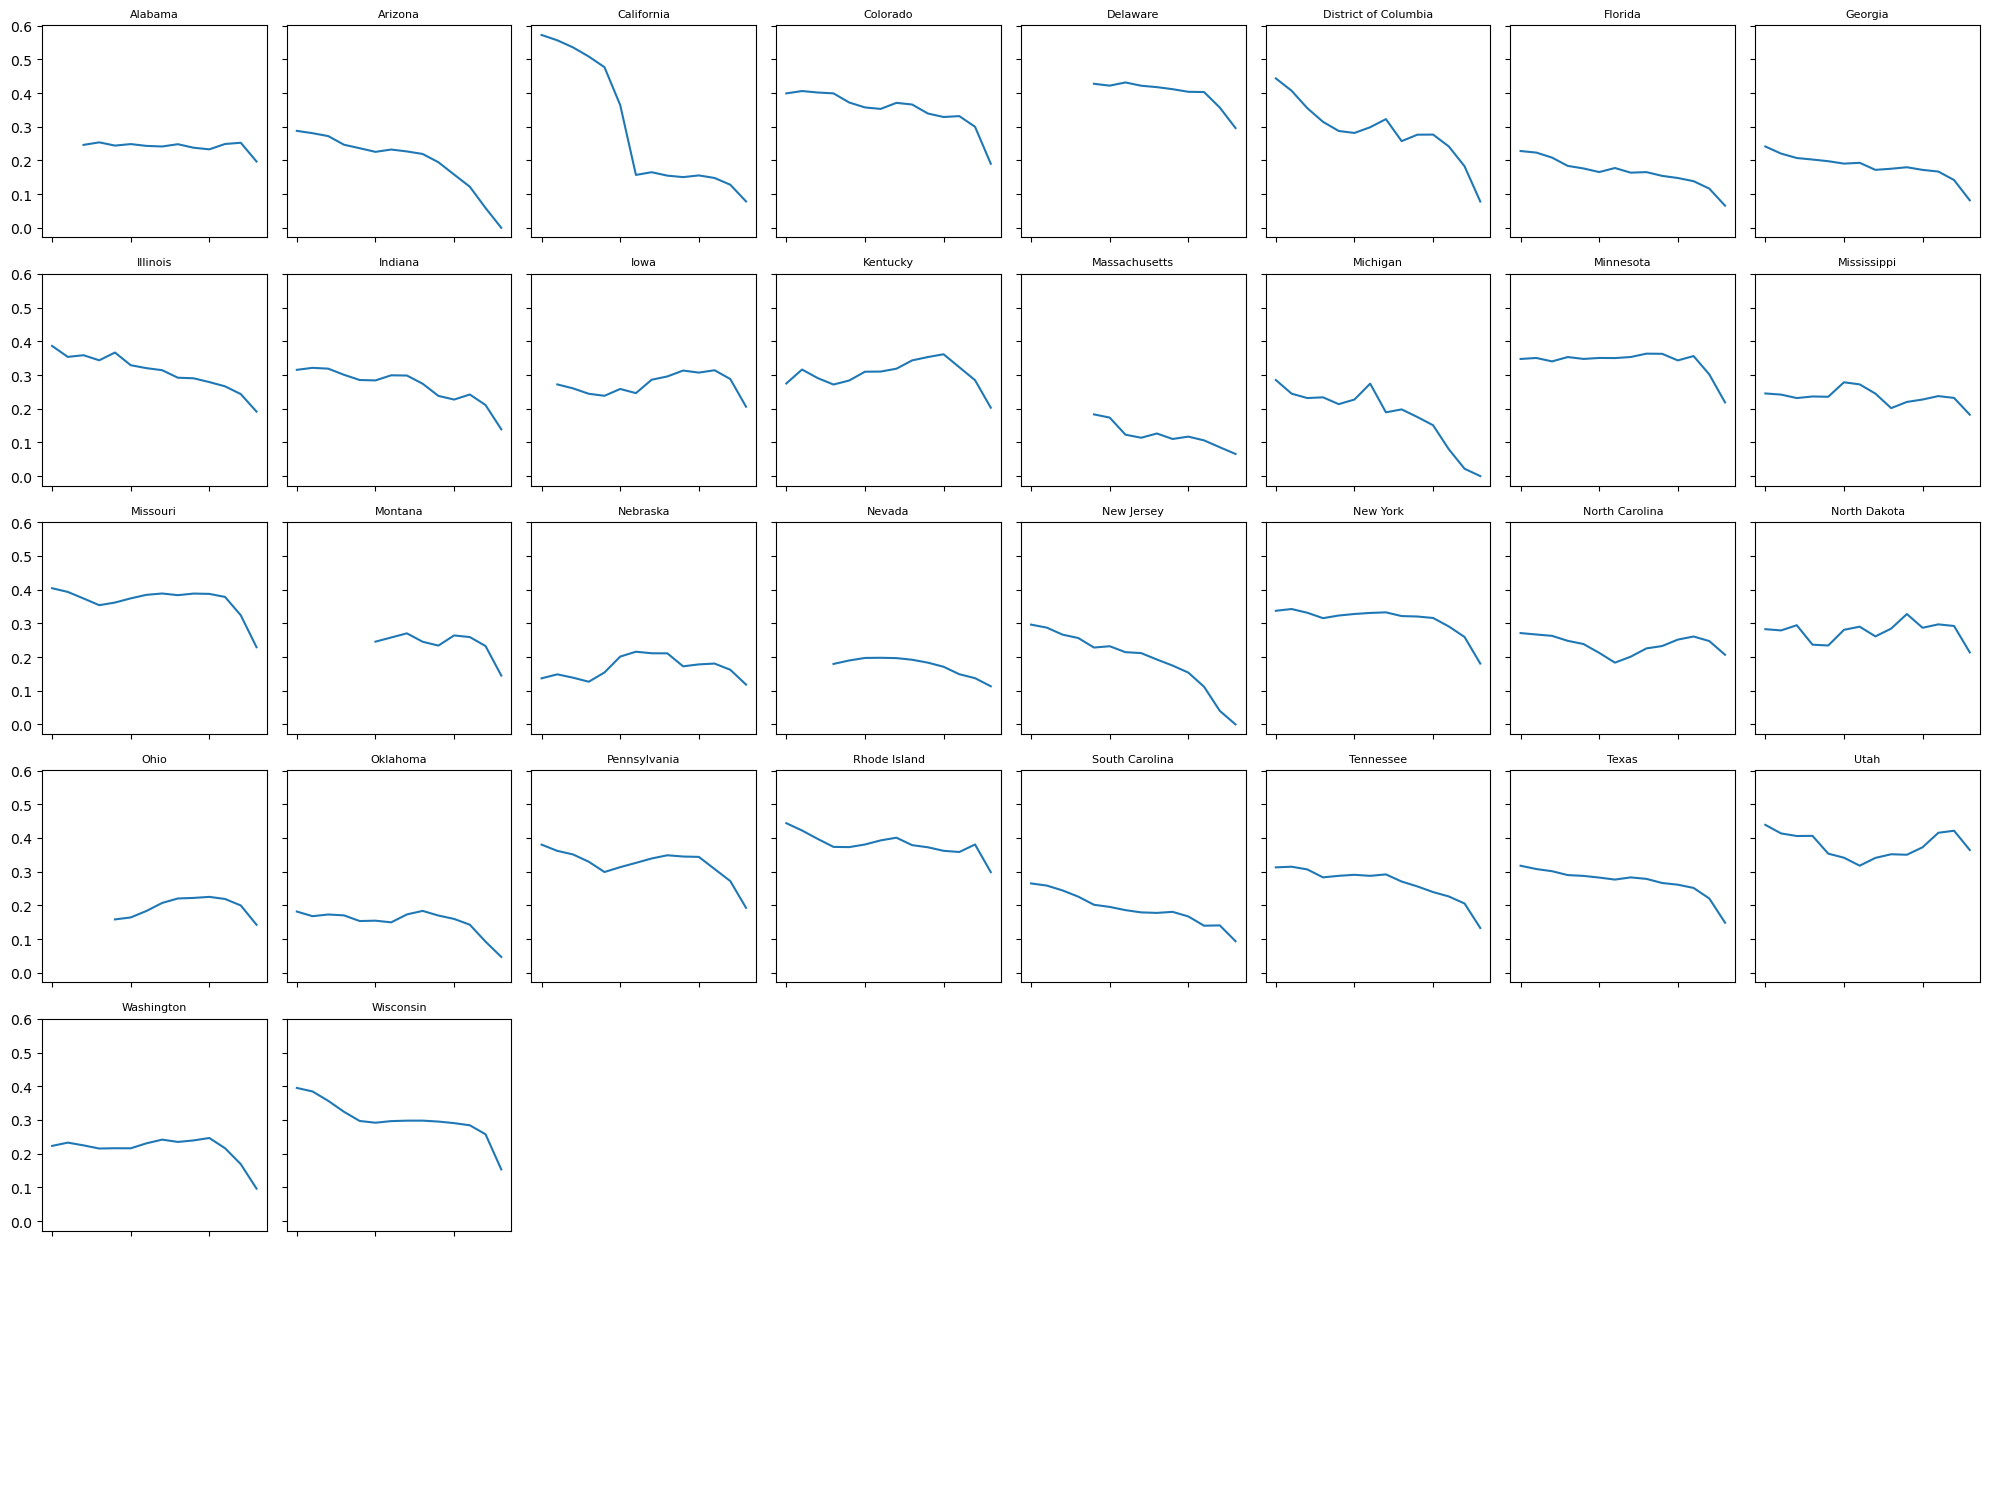

In [22]:
import matplotlib.pyplot as plt

state_trends = (
    df[(df["RELEASEYR"] >= 2005) & (df["RELEASEYR"] <= 2018)]
    .groupby(["STATE_NAME", "RELEASEYR"])["within_2_yrs"]
    .mean()
    .reset_index()
)

states = state_trends["STATE_NAME"].unique()

fig, axes = plt.subplots(6, 8, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()

for i, state in enumerate(states):
    temp = state_trends[state_trends["STATE_NAME"] == state]
    axes[i].plot(temp["RELEASEYR"], temp["within_2_yrs"])
    axes[i].set_title(state, fontsize=8)

for ax in axes[len(states) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Policy Adoptions - Additional Data


Several different policies are adopted throughout history, with some minor changes happening in the recent years - the latter more than not are facility related rather than statewide. In the interest of a DiD analysis we explore two different information sets:

1. Adoption of Second Chance Pell Experimental Sites - the adoption was through colleges, and for the purpose of our analysis we will outline the states with the largest numbers of facilities and students ellibigle.

2. Snaposhot view of Policy adoption across the three pillars (automatic enrollment, central administration, incentives) and availbaility of education in states, referenced by a 24' study.

### Adding state rankings on Education Availability and Policy Implementation

In [23]:
policy_data = [
    ["Ohio", 1, 1, 0.5, 1, 1, 1, 1, 6.5],
    ["California", 0.75, 0.75, 0.75, 1, 1, 1, 1, 6.25],
    ["Wyoming", 1, 1, 1, 1, 1, 0, 1, 6.0],
    ["Iowa", 1, 1, 1, 0.75, 1, 0, 1, 5.75],
    ["Rhode Island", 1, 1, 1, 0.5, 0, 1, 1, 5.5],
    ["Vermont", 1, 1, 1, 0.5, 0, 1, 1, 5.5],
    ["Illinois", 0.75, 0.25, 0.5, 0.75, 1, 1, 1, 5.25],
    ["New Hampshire", 0.25, 1, 1, 1, 0, 1, 1, 5.25],
    ["New York", 0.75, 0.5, 0.75, 1, 0, 1, 1, 5.0],
    ["North Dakota", 1, 1, 1, 1, 0, 0, 1, 5.0],
    ["New Jersey", 0.5, 1, 0.75, 0.5, 1, 0, 1, 4.75],
    ["West Virginia", 0.75, 0.5, 0.5, 1, 0, 1, 1, 4.75],
    ["New Mexico", 0.5, 1, 0, 1, 1, 0, 1, 4.5],
    ["South Carolina", 1, 0, 0.5, 0, 1, 1, 1, 4.5],
    ["Texas", 0.5, 0.5, 0.25, 0.25, 1, 1, 1, 4.5],
    ["Idaho", 0.5, 1, 0.75, 0, 0, 1, 1, 4.25],
    ["Tennessee", 0.75, 0.25, 0.75, 0.5, 0, 1, 1, 4.25],
    ["Connecticut", 0.5, 0.75, 0, 0.75, 0, 1, 1, 4.0],
    ["Maine", 1, 1, 1, 1, 0, 0, 0, 4.0],
    ["Oregon", 0.5, 0.5, 0.75, 0.25, 1, 0, 1, 4.0],
    ["Utah", 1, 1, 1, 0, 0, 0, 1, 4.0],
    ["Arkansas", 0.25, 0.5, 0, 0, 1, 1, 1, 3.75],
    ["Washington", 0, 1, 0.75, 1, 0, 0, 1, 3.75],
    ["Michigan", 0.75, 0.5, 0.25, 0.25, 1, 1, 0, 3.75],
    ["Mississippi", 0.5, 0.5, 0.75, 0.75, 0, 0, 1, 3.5],
    ["Colorado", 0.5, 0.5, 0.5, 0.75, 0, 0, 1, 3.25],
    ["Delaware", 0.75, 1, 0.25, 0.25, 0, 0, 1, 3.25],
    ["Indiana", 0.5, 0.5, 0.75, 0.5, 0, 0, 1, 3.25],
    ["Nebraska", 0.25, 0.25, 0.25, 0.5, 0, 1, 1, 3.25],
    ["Hawaii", 1, 1, 1, 0, 0, 0, 0, 3.0],
    ["Kansas", 1, 0, 1, 0, 0, 0, 1, 3.0],
    ["Louisiana", 0, 1, 0.25, 0.75, 0, 0, 1, 3.0],
    ["Massachusetts", 0, 0, 0.25, 0.75, 0, 1, 1, 3.0],
    ["Minnesota", 1, 1, 0, 0, 0, 1, 0, 3.0],
    ["Pennsylvania", 0.5, 0.5, 0.75, 0.25, 0, 1, 0, 3.0],
    ["Arizona", 0, 0, 0.5, 0.25, 1, 0, 1, 2.75],
    ["Kentucky", 0.25, 0.5, 0.5, 0.5, 0, 0, 1, 2.75],
    ["North Carolina", 0, 0, 0.25, 0.5, 1, 0, 1, 2.75],
    ["Oklahoma", 0.25, 0.25, 0.25, 0.75, 0, 0, 1, 2.5],
    ["Wisconsin", 0.25, 0.25, 0.5, 0.5, 0, 1, 0, 2.5],
    ["Maryland", 0.25, 0.25, 0.5, 0.25, 0, 0, 1, 2.25],
    ["Virginia", 0.25, 0.25, 0.5, 0.25, 0, 0, 1, 2.25],
    ["Florida", 0, 0, 0, 0, 1, 0, 1, 2.0],
    ["Georgia", 0.5, 0.25, 0, 0.25, 0, 0, 1, 2.0],
    ["Nevada", 0, 0, 0.25, 0.75, 0, 0, 1, 2.0],
    ["South Dakota", 1, 1, 0, 0, 0, 0, 0, 2.0],
    ["Alabama", 0, 0, 0, 0.5, 0, 0, 1, 1.5],
    ["Alaska", 0, 0, 0, 0, 0, 0, 1, 1.0],
    ["Missouri", 0.5, 0.25, 0, 0.25, 0, 0, 0, 1.0],
    ["Montana", 0, 0, 0.25, 0.75, 0, 0, 0, 1.0],
]

policy_df = pd.DataFrame(
    policy_data,
    columns=[
        "STATE_NAME",
        "ABE_Literacy",
        "Secondary",
        "Vocational",
        "College",
        "Automatic_Enrollment",
        "School_District",
        "Sentence_Reduction",
        "Total_Score",
    ],
)

df = df.merge(policy_df, on="STATE_NAME", how="left")

In [24]:
df[["STATE_NAME", "Total_Score"]].drop_duplicates().sort_values(
    "Total_Score", ascending=False
).head(20)

,STATE_NAME,Total_Score
8593371,Ohio,6.50
478741,California,6.25
5704774,Iowa,5.75
9416406,Rhode Island,5.50
4635100,Illinois,5.25
8574257,North Dakota,5.00
7456554,New York,5.00
7270278,New Jersey,4.75
9962230,Texas,4.50
9469596,South Carolina,4.50


In [25]:
df.groupby("STATE_NAME")["Total_Score"].first().sort_values(ascending=False)

STATE_NAME
Ohio                    6.50
California              6.25
Iowa                    5.75
Rhode Island            5.50
Illinois                5.25
North Dakota            5.00
New York                5.00
New Jersey              4.75
Texas                   4.50
South Carolina          4.50
Tennessee               4.25
Utah                    4.00
Washington              3.75
Michigan                3.75
Mississippi             3.50
Indiana                 3.25
Colorado                3.25
Nebraska                3.25
Delaware                3.25
Minnesota               3.00
Massachusetts           3.00
Pennsylvania            3.00
North Carolina          2.75
Kentucky                2.75
Arizona                 2.75
Oklahoma                2.50
Wisconsin               2.50
Georgia                 2.00
Florida                 2.00
Nevada                  2.00
Alabama                 1.50
Missouri                1.00
Montana                 1.00
District of Columbia     NaN
Nam

In [26]:
df["policy_tier"] = pd.qcut(df["Total_Score"], 3, labels=["Low", "Medium", "High"])


In [27]:
df.groupby("policy_tier")["within_2_yrs"].count()

policy_tier
Low       4042482
Medium    3775249
High      3685137
Name: within_2_yrs, dtype: int64

In [29]:
df.to_csv("clean_recidivism.csv", index=False)


# NCRP Variable Reference Table

## AGEADMIT — Age at Admission
| Code | Meaning |
|-----|-----|
| 1 | 18–24 years |
| 2 | 25–34 years |
| 3 | 35–44 years |
| 4 | 45–54 years |
| 5 | 55+ years |
| 9 | Missing |

---

## RACE — Race / Hispanic Ethnicity
| Code | Meaning |
|-----|-----|
| 1 | White, non-Hispanic |
| 2 | Black, non-Hispanic |
| 3 | Hispanic (any race) |
| 4 | Other race(s), non-Hispanic |
| 9 | Missing |

---

## OFFGENERAL — General Offense Category
| Code | Meaning |
|-----|-----|
| 1 | Murder (including non-negligent manslaughter) |
| 2 | Negligent manslaughter |
| 3 | Rape / sexual assault |
| 4 | Robbery |
| 5 | Aggravated or simple assault |
| 6 | Other violent offenses |
| 7 | Burglary |
| 8 | Larceny |
| 9 | Motor vehicle theft |
| 10 | Fraud |
| 11 | Other property offenses |
| 12 | Drugs (possession, distribution, trafficking, other) |
| 13 | Public order |
| 14 | Other / unspecified |
| 99 | Missing |

---

## SENTLGTH — Sentence Length
| Code | Meaning |
|-----|-----|
| Numeric value | Sentence length (months) |
| 9999 | Missing |

---

## SEX
| Code | Meaning |
|-----|-----|
| 1 | Male |
| 2 | Female |
| 9 | Missing |

---

## RELTYPE — Type of Release
| Code | Meaning |
|-----|-----|
| 1 | Mandatory release |
| 2 | Discretionary parole |
| 3 | Conditional release |
| 4 | Expiration of sentence |
| 5 | Death |
| 6 | Escape |
| 7 | Transfer |
| 8 | Other |
| 9 | Missing |

---

## OFFDETAIL — Detailed Offense Type
| Code | Meaning |
|-----|-----|
| Numeric codes | Detailed offense classification within OFFGENERAL categories |
| 99 | Missing |